## Making master dataset 

 - This Jupyter Notebook contains combining AQI and weather data, training Random Forest Regressor model and visualizing the results.

In [121]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
df1 = pd.read_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/Mod1Set_ahd.pkl')

In [11]:
df2 = pd.read_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/FinalAqi.pkl')

In [30]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 30683 entries, 0 to 30682
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   valid_time     30683 non-null  datetime64[s]
 1   blh            30683 non-null  float32      
 2   wind_speed     30683 non-null  float32      
 3   temp_gradient  30683 non-null  float32      
 4   hour           30683 non-null  int32        
 5   month          30683 non-null  int32        
 6   blh_lag_6h     30683 non-null  float32      
 7   wind_lag_6h    30683 non-null  float32      
dtypes: datetime64[s](1), float32(5), int32(2)
memory usage: 1.1 MB


In [29]:
df1.head(10)

,valid_time,blh,wind_speed,temp_gradient,hour,month,blh_lag_6h,wind_lag_6h
0,2000-01-01 12:00:00,473.053375,3.454990,-2.218750,6,1,90.085373,2.531663
1,2000-01-01 18:00:00,55.727810,1.293914,-4.384277,12,1,473.053375,3.454990
2,2000-01-02 00:00:00,63.075550,2.199284,-0.063965,18,1,55.727810,1.293914
3,2000-01-02 06:00:00,169.401291,3.457202,4.996826,0,1,63.075550,2.199284
4,2000-01-02 12:00:00,456.368317,3.458246,-2.028809,6,1,169.401291,3.457202
5,2000-01-02 18:00:00,131.031219,1.656585,-4.355225,12,1,456.368317,3.458246
6,2000-01-03 00:00:00,53.943306,2.452590,-3.242188,18,1,131.031219,1.656585
7,2000-01-03 06:00:00,152.415283,3.787549,4.027588,0,1,53.943306,2.452590
8,2000-01-03 12:00:00,417.036011,2.850808,-1.788818,6,1,152.415283,3.787549
9,2000-01-03 18:00:00,243.023422,1.804914,-4.260986,12,1,417.036011,2.850808


In [14]:
df1['valid_time'] = df1['valid_time'].values.astype('datetime64[h]')

In [25]:
df1.dropna(inplace=True)

In [28]:
df1.reset_index(inplace=True, drop=True)

In [33]:
df1.to_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/Mod1Set_ahd.pkl')

In [34]:
df2.head()

,valid_time,pm2.5
0,2015-01-28 12:00:00,36.599998
1,2015-01-28 18:00:00,120.949997
2,2015-01-29 00:00:00,136.589996
3,2015-01-29 06:00:00,90.620003
4,2015-01-29 12:00:00,68.620003


In [21]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 15962 entries, 0 to 15961
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   valid_time  15962 non-null  datetime64[s]
 1   pm2.5       13732 non-null  float32      
dtypes: datetime64[s](1), float32(1)
memory usage: 187.2 KB


In [19]:
df2.reset_index(inplace=True)

In [35]:
df2.to_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/FinalAqi.pkl')

### Merging weather and aqi data

In [36]:
madf= pd.merge(df1, df2, on='valid_time', how='inner')

In [41]:
# Forcing chronological order and move the time out of the features

madf = madf.sort_values('valid_time')
madf = madf.set_index('valid_time')

In [57]:
madf.head()

,blh,wind_speed,temp_gradient,hour,month,blh_lag_6h,wind_lag_6h,pm2.5
valid_time,,,,,,,,
2015-01-28 12:00:00,699.326782,4.081764,-4.080322,6,1,249.674286,3.329755,36.599998
2015-01-28 18:00:00,904.516907,2.176215,-4.242432,12,1,699.326782,4.081764,120.949997
2015-01-29 00:00:00,77.992821,2.554302,-1.366455,18,1,904.516907,2.176215,136.589996
2015-01-29 06:00:00,141.470749,2.571497,2.530273,0,1,77.992821,2.554302,90.620003
2015-01-29 12:00:00,510.850647,3.163714,-2.598633,6,1,141.470749,2.571497,68.620003


In [48]:
madf.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6640 entries, 2015-01-28 12:00:00 to 2021-01-01 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   blh            6640 non-null   float32
 1   wind_speed     6640 non-null   float32
 2   temp_gradient  6640 non-null   float32
 3   hour           6640 non-null   int32  
 4   month          6640 non-null   int32  
 5   blh_lag_6h     6640 non-null   float32
 6   wind_lag_6h    6640 non-null   float32
 7   pm2.5          6640 non-null   float32
dtypes: float32(6), int32(2)
memory usage: 259.4 KB


In [49]:
madf.isnull().sum()

blh              0
wind_speed       0
temp_gradient    0
hour             0
month            0
blh_lag_6h       0
wind_lag_6h      0
pm2.5            0
dtype: int64

In [45]:
madf = madf.dropna(subset=['pm2.5'])

In [58]:
madf.to_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/Mod1Set_ahd.pkl')

----------------------------------------------
### Science behind bad AQI:

Cities have concrete jungle and asphalt. These heat up and radiate heat into the atmosphere. This makes a dome of heat around the city (UHI). 

In Indian summers the sun heats the ground which heats the air at that level, the hot air rises vertically because it's lighter and cools down at high altitude. Pollutants get mixed with upper air in the troposphere. This cycle clears up local pollutants. 

Temperature Inversion: In winters, the ground cools down and continuously makes the air touching the ground cool(heavy). This cool air is colder than the air above 100 meters. Naturally cool air is heavy. So the comparatively warm air acts like a lid. This results in pollutants getting stuck under 100 meters. The wind speed is low and pollutant mixing (dispersion) height which is BLH, comes down as low as 400meters.  

Hence in winter, the vehicles radiate heat continuously until 10-11pm and concrete radiate constant heat throughout the night. The ground in winter cools down surface level air continuously while everything else still heats up the air above. If the air speed is slow and cities are designed like canyons, this makes a heat dome. Interrupts wind patterns, traps pollutants at breathing level, often generating irritant gasses like O3-Ozone and raising AQI.  

----------------------------------------------

### Challenge: 
Accurately predicting when and to what extent PM 2.5 levels will spike based on
atmospheric conditions.

### Objective: 
While current systems report existing pollution, there is a crucial need to forecast
sudden "evening compression" spikes caused by shifting weather, allowing for proactive urban
management.

----------------------------------------------

### Training the Model

- Random Forest Regressor is being used here to make the model.

- Reason: RF is non linear algorithm. Unlike linear regression or some algorithm who tries to fit a curve, RF is suitable when data has variaty. RF is am ensemble technique because it trains multiple decesion trees that create branches to minimize the variance. It is less sensitive to outliers.

- The weather data is always inconsistent and have outliers hence RF is chosen here.

In [122]:
madf = pd.read_pickle('/Users/meetdave/Public/AqiPred/Final Datasets/Mod1Set_ahd.pkl')

In [123]:
madf.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6640 entries, 2015-01-28 12:00:00 to 2021-01-01 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   blh            6640 non-null   float32
 1   wind_speed     6640 non-null   float32
 2   temp_gradient  6640 non-null   float32
 3   hour           6640 non-null   int32  
 4   month          6640 non-null   int32  
 5   blh_lag_6h     6640 non-null   float32
 6   wind_lag_6h    6640 non-null   float32
 7   pm2.5          6640 non-null   float32
dtypes: float32(6), int32(2)
memory usage: 259.4 KB


In [124]:
madf.tail()

,blh,wind_speed,temp_gradient,hour,month,blh_lag_6h,wind_lag_6h,pm2.5
valid_time,,,,,,,,
2020-12-31 00:00:00,248.124496,3.638149,0.522461,18,12,425.335571,2.595206,84.959999
2020-12-31 06:00:00,342.521393,4.459709,2.329346,0,12,248.124496,3.638149,71.589996
2020-12-31 12:00:00,514.722351,4.473258,-2.306885,6,12,342.521393,4.459709,70.339996
2020-12-31 18:00:00,275.974609,1.744916,-4.183594,12,12,514.722351,4.473258,129.729996
2021-01-01 00:00:00,85.388367,2.212443,0.744629,18,12,275.974609,1.744916,101.260002


In [125]:
cutoff_date = '2020-01-01'

In [126]:
#chornological split because TSA

train_data = madf[madf.index < cutoff_date]
test_data = madf[madf.index >= cutoff_date]

In [127]:
feature_cols = ['blh', 'wind_speed', 'temp_gradient', 'hour', 'month', 'blh_lag_6h', 'wind_lag_6h']

In [128]:
print(feature_cols)

['blh', 'wind_speed', 'temp_gradient', 'hour', 'month', 'blh_lag_6h', 'wind_lag_6h']


In [129]:
X_train = train_data[feature_cols]
y_train = train_data['pm2.5']

In [130]:
X_test = test_data[feature_cols]
y_test = test_data['pm2.5']

In [131]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


In [132]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [133]:
predictions = rf_model.predict(X_test)

In [134]:
mae = mean_absolute_error(y_test, predictions) 

In [135]:
r2 = r2_score(y_test, predictions)

In [136]:
print(f"Mean Absolute Error: {mae:.2f} PM2.5 units")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error: 51.38 PM2.5 units
R-squared Score: -0.87


#### - The split for this data is 2015 to 2020 and 2020 to 2021. The model trained the data on usual period data. But tried to guess air quality for data in covid-19 period. Because emissions inside Ahmedabad (All cities) were none in covid-19 area, the model couldn't predict it. This explains high value of MEA and negative R squared score.
#### - The physics of inversion surely happened in the environment after 2020 but there were no pollutants to entrap!
#### - This identifies a major feature that while the atmmosphere creates a perticular situation for pollution to stay inside cities, if emissions are regulated dynamically, pollution can be controlled easily!

In [137]:
importances = rf_model.feature_importances_

feature_ranking = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_ranking)

         Feature  Importance
0            blh    0.284059
2  temp_gradient    0.175604
1     wind_speed    0.162686
5     blh_lag_6h    0.153406
6    wind_lag_6h    0.132848
4          month    0.081383
3           hour    0.010013


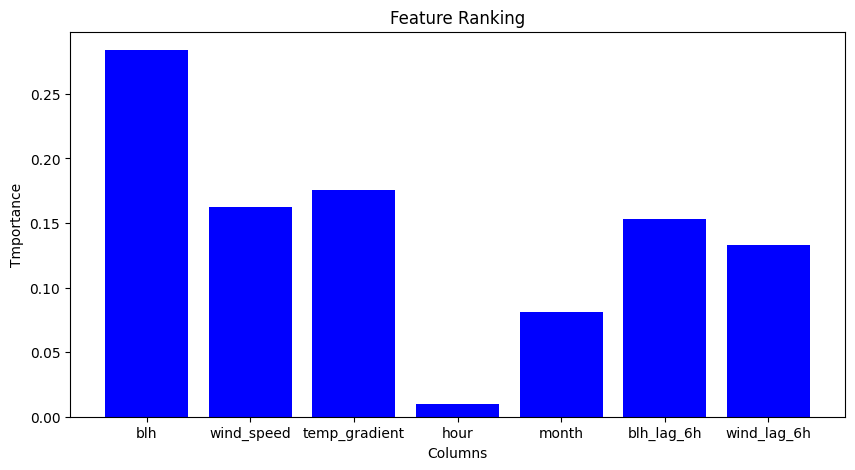

In [141]:
plt.figure(figsize=(10, 5))
plt.bar(feature_cols, importances2, color = 'blue')
plt.title('Feature Ranking')
plt.xlabel('Columns')
plt.ylabel('Tmportance')
plt.show() 

#### BLH and temp_grad being on top implies that model relied on these 2 the most, to predict on the test data

### Checking if anomaly happened due to covid

In [22]:
train_data2 = madf[(madf.index > '2015-01-01') & (madf.index < '2019-01-01')]
test_data2 = madf[(madf.index >= '2019-01-01') & (madf.index < '2020-01-01')] #year 2019 

In [23]:
X_train2 = train_data2[feature_cols]
y_train2 = train_data2['pm2.5']

In [24]:
X_test2 = test_data2[feature_cols]
y_test2 = test_data2['pm2.5']

In [25]:
rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [26]:
rf_model2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
predictions2 = rf_model2.predict(X_test2)

In [28]:
mae2 = mean_absolute_error(y_test2, predictions2) 

In [29]:
R2 = r2_score(y_test2, predictions2)

In [30]:
print(f"Mean Absolute Error: {mae2:.2f} PM2.5 units")
print(f"R-squared Score: {R2:.2f}")

Mean Absolute Error: 13.27 PM2.5 units
R-squared Score: 0.86


In [31]:
importances2 = rf_model2.feature_importances_

feature_ranking2 = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances2
}).sort_values(by='Importance', ascending=False)

print(feature_ranking2)

         Feature  Importance
0            blh    0.284059
2  temp_gradient    0.175604
1     wind_speed    0.162686
5     blh_lag_6h    0.153406
6    wind_lag_6h    0.132848
4          month    0.081383
3           hour    0.010013


#### Mean Absolute Error: 13.27, PM2.5 units, $R^2$ Score: 0.86 implies that years around 2020 were an anomaly because emission was almost zero

### Visualizing 

In [46]:
import matplotlib.pyplot as plt

In [42]:
results = pd.DataFrame({'Actual': y_test2, 'Predicted': predictions2}, index=y_test2.index)

In [43]:
print(results)

                         Actual   Predicted
valid_time                                 
2019-01-01 00:00:00  204.199997  188.289892
2019-01-01 06:00:00   98.320000  107.293900
2019-01-01 12:00:00   97.970001  110.612775
2019-01-01 18:00:00  275.000000  253.830889
2019-01-02 00:00:00  309.170013  250.002808
...                         ...         ...
2019-12-30 18:00:00  147.899994  143.477547
2019-12-31 00:00:00   79.410004   97.912119
2019-12-31 06:00:00   80.230003   92.228802
2019-12-31 12:00:00   61.840000   79.473389
2019-12-31 18:00:00  157.949997  129.619098

[1406 rows x 2 columns]


In [100]:
week_slice = results.loc['2019-01-01':'2019-01-07']

#### - Filtering the data for a week in january because in winters, boundary layer height drops and temperature inversion happens. 

In [45]:
print(week_slice)

                         Actual   Predicted
valid_time                                 
2019-01-01 00:00:00  204.199997  188.289892
2019-01-01 06:00:00   98.320000  107.293900
2019-01-01 12:00:00   97.970001  110.612775
2019-01-01 18:00:00  275.000000  253.830889
2019-01-02 00:00:00  309.170013  250.002808
2019-01-02 06:00:00  176.229996  208.592779
2019-01-02 12:00:00  141.729996  130.467345
2019-01-02 18:00:00  297.709991  257.069395
2019-01-03 00:00:00  303.660004  270.548702
2019-01-03 06:00:00  110.059998  123.896665
2019-01-03 12:00:00   84.989998   99.365398
2019-01-03 18:00:00  222.630005  196.814203
2019-01-04 00:00:00  177.809998  193.973933
2019-01-04 06:00:00   89.010002  109.986534
2019-01-04 12:00:00  104.279999  104.832299
2019-01-04 18:00:00  165.990005  201.522204
2019-01-05 00:00:00  174.070007  210.887748
2019-01-05 06:00:00  128.750000  138.118100
2019-01-05 12:00:00  131.169998  131.981899
2019-01-05 18:00:00  150.649994  156.813796
2019-01-06 00:00:00  159.869995 

#### - Plotting actual PM2.5 data with values predicted by the model: 

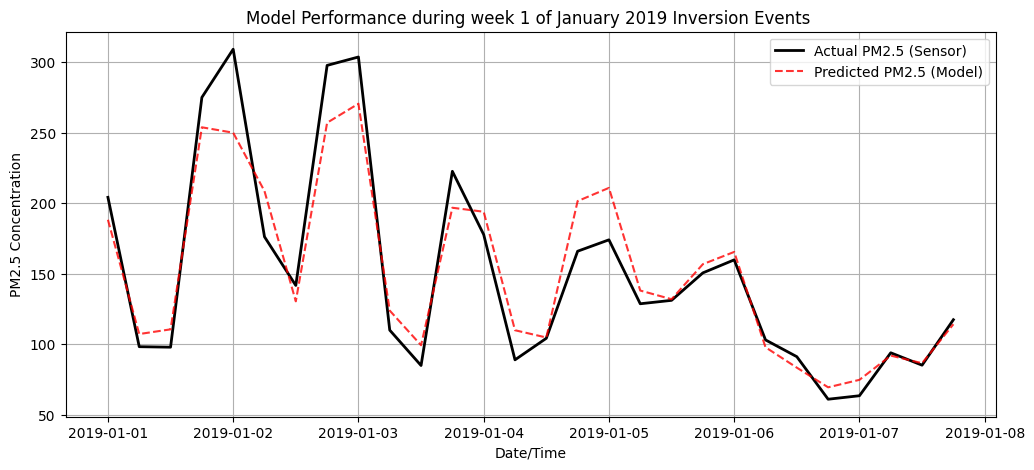

In [115]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
axes.plot(week_slice.index, week_slice['Actual'], label='Actual PM2.5 (Sensor)', color='black', linewidth=2)
axes.plot(week_slice.index, week_slice['Predicted'], label='Predicted PM2.5 (Model)', color='red', linestyle='--', alpha=0.8)
axes.set_title("Model Performance during week 1 of January 2019 Inversion Events ")
axes.set_xlabel("Date/Time")
axes.set_ylabel("PM2.5 Concentration")
axes.legend()
axes.grid(True)
plt.show()

Here black line represents actual PM2.5 values recorded in sensor. It can clearly be seen that the dashed red line follows black lines (actual values) which displays the magnitude of the accuracy of the model.

#### - Plotting data of just one day to observe Temperature Inversion.

In [116]:
slice2 = results.loc['2019-01-01':'2019-01-02']

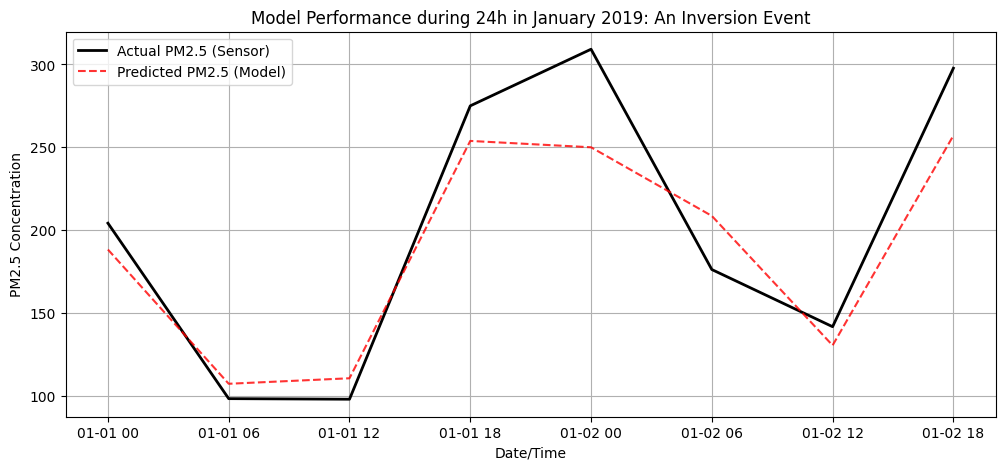

In [118]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
axes.plot(slice2.index, slice2['Actual'], label='Actual PM2.5 (Sensor)', color='black', linewidth=2)
axes.plot(slice2.index, slice2['Predicted'], label='Predicted PM2.5 (Model)', color='red', linestyle='--', alpha=0.8)
axes.set_title("Model Performance during 24h in January 2019: An Inversion Event")
axes.set_xlabel("Date/Time")
axes.set_ylabel("PM2.5 Concentration")
axes.grid(True)
axes.legend()
plt.show()

Here the phenomenon of Temperature Inversion can be seen. Pollutant value rises after 12PM. The boundary layer starts shrinking more after the noon. Around 6PM the emissions rise to the peak. Now because low boundary layer height, slow winds and too much emissions, the pollution keeps rising till midnight which the plot indicates. The spike between  12PM to 6AM suggests the entrapment of pollution.